<a href="https://colab.research.google.com/github/Sathwik2202/Simple-Projects/blob/main/Breast_cancer_QR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 0. Introduction

In this notebook, we will explore various feature selection and dimensionality reduction techniques in reference to the [Wisconsin breast cancer dataset](https://www.kaggle.com/uciml/breast-cancer-wisconsin-data) on Kaggle. This dataset contains 569 breast cancer observations in which 357 of them are benign and 212 of them are malignant. The goal is to train a machine learning model that is able to classify a random breast cancer observation as either benign or malignant.

# 1. Import libraries

In [ ]:
# Data wrangling
import pandas as pd
import numpy as np

# Data visualisation
import seaborn as sns
import matplotlib.pyplot as plt

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.feature_selection import VarianceThreshold, SelectKBest, chi2, RFE, RFECV
from sklearn.decomposition import PCA

# Remove warnings
import warnings
warnings.filterwarnings('ignore')

# 2. Import and read data

In [ ]:
data = pd.read_csv("data.csv")
data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [ ]:
print("Shape of dataframe: ", data.shape)

Shape of dataframe:  (569, 33)


# 3. Check for missing values

In [ ]:
# Missing data

missing = data.isnull().sum()
missing[missing > 0]

,0
Unnamed: 32,569


Unnamed is the only column with missing values in the dataframe. In fact, the entire column is missing so it is safe for us to drop the column.

I will also remove the id column as it does not provide us with any information regarding the classification of cancer cells.

In [ ]:
# Drop ID and Unnamed columns

print("Before: ", data.shape)
data = data.drop(['id', 'Unnamed: 32'], axis = 1)
print("After: ", data.shape)

Before:  (569, 33)
After:  (569, 31)


# 4. Data description

In [ ]:
data.dtypes.value_counts()

,count
float64,30
object,1


We have 30 numerical variables and only 1 categorical variable, which is our target variable (diagnosis). Let's have a look at these features in detail.

In [ ]:
data.dtypes

,0
diagnosis,object
radius_mean,float64
texture_mean,float64
perimeter_mean,float64
area_mean,float64
smoothness_mean,float64
compactness_mean,float64
concavity_mean,float64
concave points_mean,float64
symmetry_mean,float64


According to the [data description](https://www.kaggle.com/uciml/breast-cancer-wisconsin-data) of this dataset, the columns represent 10 real-valued features of each cell nucleus:

1. Radius
2. Texture
3. Perimeter
4. Area
5. Smoothness
6. Compactness
7. Concavity
8. Concave points
9. Symmetry
10. Fractal dimension

The mean, standard error and worst of each feature were also computed, resulting in a total of 10 x 3 = 30 features (columns) in the dataset excluding the target variable.

Just by the names of the features itself, we can already foresee some issues of multicollinearity. The most obvious being between radius, perimeter and area. But before we deal with the issue of multicollinearity, let's first standardise our data and divide the features into 3 groups:

- feature_mean
- feature_se
- feature_worst

In [ ]:
# Standardise all features so that they follow a standard Gaussian distribution

original_features = data.drop('diagnosis', axis = 1)
standard_features = (original_features - original_features.mean()) / original_features.std()
standard_data = pd.concat([data['diagnosis'], standard_features], axis = 1)

In [ ]:
# Divide the standardised features into 3 groups

feature_mean = standard_data.iloc[:, 1:11]
feature_se = standard_data.iloc[:, 11: 21]
feature_worst = standard_data.iloc[:, 21:31]

Now, we can move on to exploring the features in the dataset.

# 5. Exploratory data analysis (EDA)

In [ ]:
standard_data.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,1.096100,-2.071512,1.268817,0.983510,1.567087,3.280628,2.650542,2.530249,2.215566,...,1.885031,-1.358098,2.301575,1.999478,1.306537,2.614365,2.107672,2.294058,2.748204,1.935312
1,M,1.828212,-0.353322,1.684473,1.907030,-0.826235,-0.486643,-0.023825,0.547662,0.001391,...,1.804340,-0.368879,1.533776,1.888827,-0.375282,-0.430066,-0.146620,1.086129,-0.243675,0.280943
2,M,1.578499,0.455786,1.565126,1.557513,0.941382,1.052000,1.362280,2.035440,0.938859,...,1.510541,-0.023953,1.346291,1.455004,0.526944,1.081980,0.854222,1.953282,1.151242,0.201214
3,M,-0.768233,0.253509,-0.592166,-0.763792,3.280667,3.399917,1.914213,1.450431,2.864862,...,-0.281217,0.133866,-0.249720,-0.549538,3.391291,3.889975,1.987839,2.173873,6.040726,4.930672
4,M,1.748758,-1.150804,1.775011,1.824624,0.280125,0.538866,1.369806,1.427237,-0.009552,...,1.297434,-1.465481,1.337363,1.219651,0.220362,-0.313119,0.612640,0.728618,-0.867590,-0.396751


# 5.1 Target variable

In [ ]:
# Encode target variable

data['diagnosis'] = data['diagnosis'].map({'B': 0, 'M': 1})
standard_data = data.copy()
print(data)

     diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0          NaN        17.99         10.38          122.80     1001.0   
1          NaN        20.57         17.77          132.90     1326.0   
2          NaN        19.69         21.25          130.00     1203.0   
3          NaN        11.42         20.38           77.58      386.1   
4          NaN        20.29         14.34          135.10     1297.0   
..         ...          ...           ...             ...        ...   
564        NaN        21.56         22.39          142.00     1479.0   
565        NaN        20.13         28.25          131.20     1261.0   
566        NaN        16.60         28.08          108.30      858.1   
567        NaN        20.60         29.33          140.10     1265.0   
568        NaN         7.76         24.54           47.92      181.0   

     smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0            0.11840           0.27760         0.30010  

In [ ]:
# Value counts

target = data['diagnosis']
print(data["diagnosis"].isna().sum())
target.value_counts()

0


,count
diagnosis,
0,357
1,212


# 5.2 Predictor variables

## 5.2.1 Issue of multicollinearity

<Axes: title={'center': 'Correlation Between Predictor Variables'}>

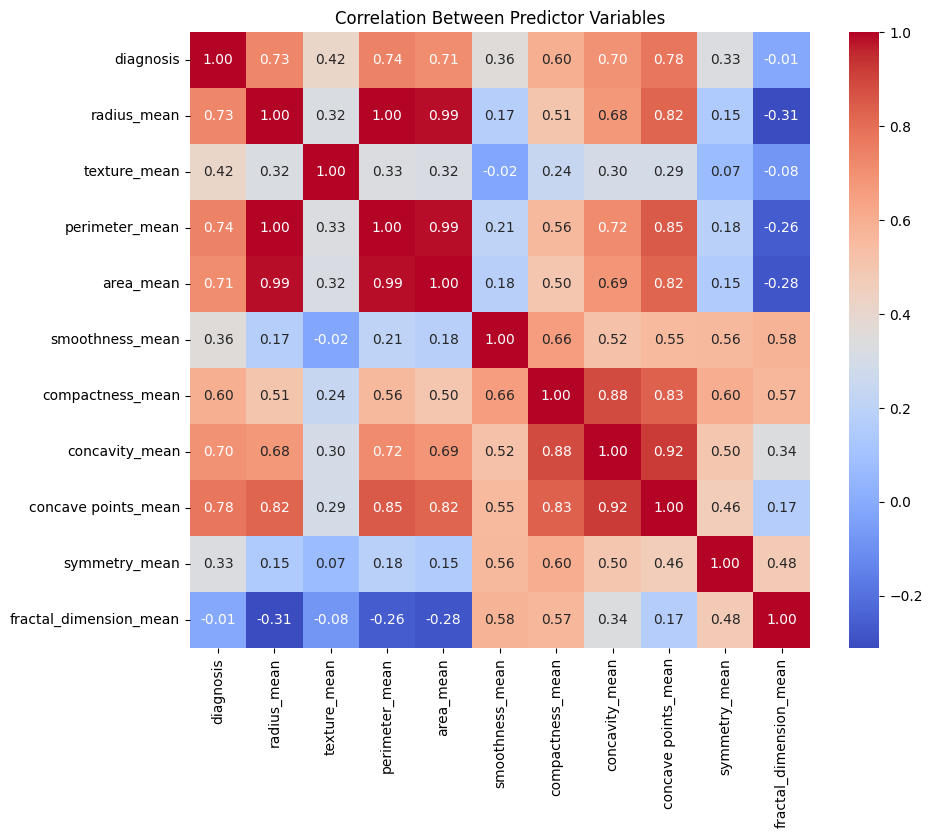

In [ ]:
# Heatmap

correlation = feature_mean.corr()
plt.figure(figsize = (10, 8))
plt.title('Correlation Between Predictor Variables')
sns.heatmap(correlation, annot = True, fmt = '.2f', cmap = 'coolwarm')

As expected, we have a severe problem of multicollinearity in our data. From the heatmap, we can observe that the following features are positively correlated with each other:

- Radius
- Perimeter
- Area
- Compactness
- Concavity
- Concave points

## 5.2.2 Explore the relationship between predictor variables and target variable

In this section, we will visualise the relationship between our predictor variables and the target variable. The goal here is to investigate and determine the features that are most important at distinguishing whether a cancer cell is benign or malignant.

In [ ]:
feature_mean = pd.concat([target, feature_mean], axis = 1)
feature_mean.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean
0,1,1.096100,-2.071512,1.268817,0.983510,1.567087,3.280628,2.650542,2.530249,2.215566,2.253764
1,1,1.828212,-0.353322,1.684473,1.907030,-0.826235,-0.486643,-0.023825,0.547662,0.001391,-0.867889
2,1,1.578499,0.455786,1.565126,1.557513,0.941382,1.052000,1.362280,2.035440,0.938859,-0.397658
3,1,-0.768233,0.253509,-0.592166,-0.763792,3.280667,3.399917,1.914213,1.450431,2.864862,4.906602
4,1,1.748758,-1.150804,1.775011,1.824624,0.280125,0.538866,1.369806,1.427237,-0.009552,-0.561956


In [ ]:
mean_melt = pd.melt(feature_mean, id_vars = 'diagnosis', var_name = 'feature', value_name = 'value')
mean_melt.head()

,diagnosis,feature,value
0,1,radius_mean,1.096100
1,1,radius_mean,1.828212
2,1,radius_mean,1.578499
3,1,radius_mean,-0.768233
4,1,radius_mean,1.748758


Again, this plot illustrates that fractal dimension is not as good at classifying cancer cells as the other features in the dataset.

Boxplot also allows us to analyse the outliers in our dataset but let's ignore this problem for now.

# 6. Feature selection

Now that we have a better sense of our data, we can move on to selecting features for our training set to build our model.

Before we do that, let's set a base case for our feature selection i.e. use all the features in the dataset to train our model.

In [ ]:
data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


Here, I will assign 70% of the dataset as the training set and the remaining 30% as the test set to test the accuracy of our model.

In [ ]:
# Train test split

X_train, X_test, Y_train, Y_test = train_test_split(original_features, target, test_size = 0.3, random_state = 10)
print("X_train shape: ", X_train.shape)
print("Y_train shape: ", Y_train.shape)
print("X_test shape: ", X_test.shape)
print("Y_test shape: ", Y_test.shape)

X_train shape:  (398, 30)
Y_train shape:  (398,)
X_test shape:  (171, 30)
Y_test shape:  (171,)


# 6.1 Base case

In [ ]:
# Fit random forest classifier to training set and make predictions on test set

rf = RandomForestClassifier(random_state = 42)
rf.fit(X_train, Y_train)
Y_pred = rf.predict(X_test)

Accuracy: 98.25%
F1 score: 0.98


<Axes: >

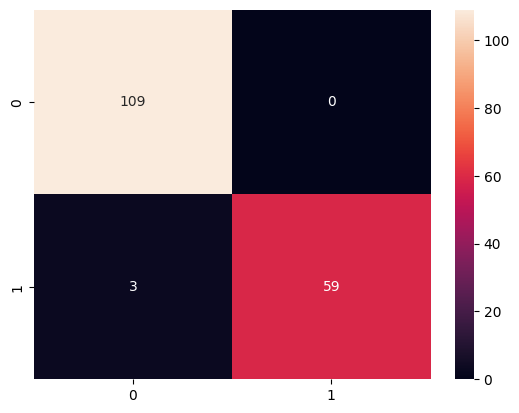

In [ ]:
# Evaluate model accuracy

accuracy = accuracy_score(Y_pred, Y_test) * 100
print("Accuracy: {:.2f}%".format(accuracy))
f1 = f1_score(Y_pred, Y_test)
print("F1 score: {:.2f}".format(f1))
cm = confusion_matrix(Y_pred, Y_test)
sns.heatmap(cm, annot = True, fmt = 'd')

In [ ]:
print(original_features)

     radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
0          17.99         10.38          122.80     1001.0          0.11840   
1          20.57         17.77          132.90     1326.0          0.08474   
2          19.69         21.25          130.00     1203.0          0.10960   
3          11.42         20.38           77.58      386.1          0.14250   
4          20.29         14.34          135.10     1297.0          0.10030   
..           ...           ...             ...        ...              ...   
564        21.56         22.39          142.00     1479.0          0.11100   
565        20.13         28.25          131.20     1261.0          0.09780   
566        16.60         28.08          108.30      858.1          0.08455   
567        20.60         29.33          140.10     1265.0          0.11780   
568         7.76         24.54           47.92      181.0          0.05263   

     compactness_mean  concavity_mean  concave points_mean  sym

In [ ]:
from scipy.linalg import qr, svd
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
Xc = scaler.fit_transform(original_features)
Q, R = qr(Xc, mode='economic')

# --------------------------------------------------
# STEP 2: SVD of R
# --------------------------------------------------
U_tilde, S, VT = svd(R)

V = VT.T   # principal components

# --------------------------------------------------
# Principal component scores
k = 5

V_k = V[:, :k]

# --------------------------------------------------
X_qrsvd_5 = original_features @ V_k
print(X_qrsvd_5)


              0           1          2           3          4
0   -793.364674  772.386400  28.693570  114.456637  61.498704
1   -831.376304  819.573038  21.695304  113.079259  46.296461
2   -751.111800  737.924156  26.218798   98.643829  44.035575
3   -271.973741  262.394926   4.912013   14.387632  15.271273
4   -741.248858  730.596479  30.886047  110.336027  38.163621
..          ...         ...        ...         ...        ...
564 -904.399203  887.916357  44.709909  128.359133  58.179018
565 -772.937544  758.802048  29.407552   90.168986  46.543022
566 -522.486870  512.141833  15.075822   48.895637  27.853743
567 -801.865190  785.872631  23.540833   91.031488  46.660824
568 -139.519596  132.514150   3.779765  -12.267499  10.284296

[569 rows x 5 columns]


In [ ]:
from sklearn.preprocessing import MinMaxScaler
qrsvd_features = pd.DataFrame(
    MinMaxScaler().fit_transform(X_qrsvd_5),
    columns=["PC1","PC2","PC3","PC4","PC5"]
)

In [ ]:
qrsvd_features.head()

,PC1,PC2,PC3,PC4,PC5
0,0.580531,0.419627,0.185790,0.440001,0.367935
1,0.557382,0.449060,0.138980,0.435374,0.267506
2,0.606263,0.398131,0.169237,0.386886,0.252570
3,0.898058,0.101513,0.026720,0.103869,0.062548
4,0.612269,0.393560,0.200455,0.426160,0.213779


Our model achieved an accuracy of 98.25%. Not too shabby at all.

Let's now explore the different feature selection and dimensionality reduction techniques and see if we can achieve a similar level of accuracy but with a smaller training set i.e. less features.

Unsurprisingly, the top 5 features with the highest VIF are the suspects that we have already identified earlier on.

431    0
389    1
309    0
111    0
35     1
      ..
369    1
320    0
527    0
125    0
265    1
Name: diagnosis, Length: 398, dtype: int64
Accuracy: 95.32%
F1 score: 0.93


<Axes: >

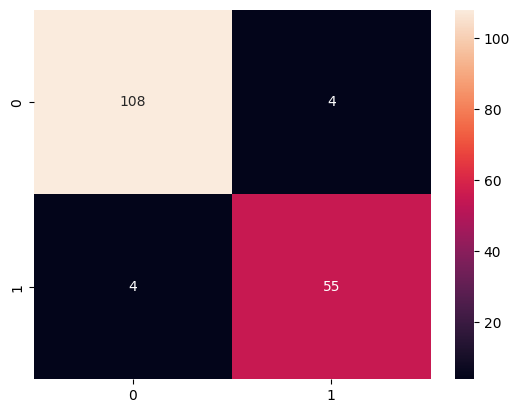

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(
    qrsvd_features,
    target,
    test_size=0.3,
    random_state=10,
    stratify=target
)

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, Y_train)
# Train test split
X_train, X_test, Y_train, Y_test = train_test_split(qrsvd_features, target, test_size = 0.3, random_state = 10)
print(Y_train)
# Fit model to data and make predictions
rf = RandomForestClassifier(random_state = 42)
rf.fit(X_train, Y_train)
Y_pred = rf.predict(X_test)

# Evaluate model accuracy
accuracy = accuracy_score(Y_pred, Y_test) * 100
print("Accuracy: {:.2f}%".format(accuracy))
f1 = f1_score(Y_pred, Y_test)
print("F1 score: {:.2f}".format(f1))
cm = confusion_matrix(Y_pred, Y_test)
sns.heatmap(cm, annot = True, fmt = 'd')

After removing the top 5 features with the highest VIF, our model accuracy not only did not decrease but instead it increased marginally.